# Decision Trees

Decision trees are a supervised learning model that maps feature values to target predictions using a tree-like structure of decision rules. Each internal node tests a feature, branches represent test outcomes, and leaf nodes give class labels or continuous values. Trees are built by recursively splitting the data to maximize purity (e.g., using Gini impurity or information gain) and can handle both categorical and numerical features. They are highly interpretable and fast to evaluate, but prone to overfitting; pruning or limiting depth helps generalization. Common uses include classification and regression, and trees often serve as base learners in ensemble methods like random forests and gradient boosting for improved performance.

In [33]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
from pathlib import Path

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

# Add the libs directory to Python path
current_dir = Path.cwd()
libs_dir = os.path.join(current_dir, '..', 'libs')
libs_dir = os.path.abspath(libs_dir)
print("Libs directory:", libs_dir)
sys.path.insert(0, libs_dir)

from utils import get_numerical_and_non_numerical_heatmap

dataset_dir = os.path.join(current_dir, '..', 'datasets')
models_dir = os.path.join(current_dir, '..', 'models')

ws_url = "ws://localhost:8000/ws"

Libs directory: /Users/kolithawarnakulasooriya/Projects/AI-driven-cyber-physical-system/libs


In [3]:
df = pd.read_csv(f"{dataset_dir}/firewall_data.csv")
df.head()

,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Action,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
0,57222,53,54587,53,allow,177,94,83,2,30,1,1
1,56258,3389,56258,3389,allow,4768,1600,3168,19,17,10,9
2,6881,50321,43265,50321,allow,238,118,120,2,1199,1,1
3,50553,3389,50553,3389,allow,3327,1438,1889,15,17,8,7
4,50002,443,45848,443,allow,25358,6778,18580,31,16,13,18


In [4]:
df.describe()

,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
count,65532.000000,65532.000000,65532.000000,65532.000000,6.553200e+04,6.553200e+04,6.553200e+04,6.553200e+04,65532.000000,65532.000000,65532.000000
mean,49391.969343,10577.385812,19282.972761,2671.049930,9.712395e+04,2.238580e+04,7.473815e+04,1.028660e+02,65.833577,41.399530,61.466505
std,15255.712537,18466.027039,21970.689669,9739.162278,5.618439e+06,3.828139e+06,2.463208e+06,5.133002e+03,302.461762,3218.871288,2223.332271
min,0.000000,0.000000,0.000000,0.000000,6.000000e+01,6.000000e+01,0.000000e+00,1.000000e+00,0.000000,1.000000,0.000000
25%,49183.000000,80.000000,0.000000,0.000000,6.600000e+01,6.600000e+01,0.000000e+00,1.000000e+00,0.000000,1.000000,0.000000
50%,53776.500000,445.000000,8820.500000,53.000000,1.680000e+02,9.000000e+01,7.900000e+01,2.000000e+00,15.000000,1.000000,1.000000
75%,58638.000000,15000.000000,38366.250000,443.000000,7.522500e+02,2.100000e+02,4.490000e+02,6.000000e+00,30.000000,3.000000,2.000000
max,65534.000000,65535.000000,65535.000000,65535.000000,1.269359e+09,9.484772e+08,3.208818e+08,1.036116e+06,10824.000000,747520.000000,327208.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65532 entries, 0 to 65531
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Source Port           65532 non-null  int64
 1   Destination Port      65532 non-null  int64
 2   NAT Source Port       65532 non-null  int64
 3   NAT Destination Port  65532 non-null  int64
 4   Action                65532 non-null  str  
 5   Bytes                 65532 non-null  int64
 6   Bytes Sent            65532 non-null  int64
 7   Bytes Received        65532 non-null  int64
 8   Packets               65532 non-null  int64
 9   Elapsed Time (sec)    65532 non-null  int64
 10  pkts_sent             65532 non-null  int64
 11  pkts_received         65532 non-null  int64
dtypes: int64(11), str(1)
memory usage: 6.0 MB


In [6]:
df.isnull().sum()

Source Port             0
Destination Port        0
NAT Source Port         0
NAT Destination Port    0
Action                  0
Bytes                   0
Bytes Sent              0
Bytes Received          0
Packets                 0
Elapsed Time (sec)      0
pkts_sent               0
pkts_received           0
dtype: int64

In [58]:
df.isna().sum()

Source Port             0
Destination Port        0
NAT Source Port         0
NAT Destination Port    0
Action                  0
Bytes                   0
Bytes Sent              0
Bytes Received          0
Packets                 0
Elapsed Time (sec)      0
pkts_sent               0
pkts_received           0
dtype: int64

In [7]:
columns = df.columns.drop(['Source Port', 'Destination Port', 'NAT Source Port','NAT Destination Port'])
columns

Index(['Action', 'Bytes', 'Bytes Sent', 'Bytes Received', 'Packets',
       'Elapsed Time (sec)', 'pkts_sent', 'pkts_received'],
      dtype='str')

### Check the correlation,
Because our data is numerical feature and non neumerical target, we use Cramér's V

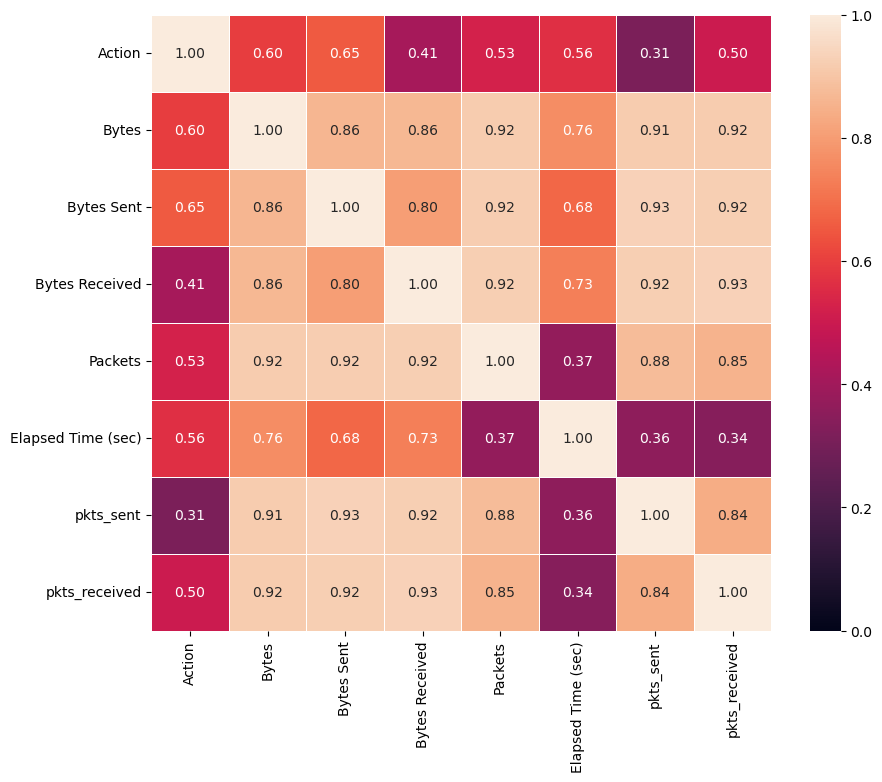

In [10]:
df = df[columns.values.tolist()]

plt.figure(figsize=(10, 8))
sns.heatmap(get_numerical_and_non_numerical_heatmap(df, columns), annot=True, vmin=0, vmax=1, fmt=".2f",linewidths=0.5)
plt.show()

In [11]:
X = df[df.columns.drop('Action').values.tolist()]
y = df[['Action']]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
classifier = DecisionTreeClassifier(max_depth=3, random_state=42)
classifier.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

[Text(0.5769230769230769, 0.875, 'Elapsed Time (sec) <= 0.5\ngini = 0.58\nsamples = 52425\nvalue = [30095, 11993, 10289, 48]\nclass = allow'),
 Text(0.3076923076923077, 0.625, 'Bytes <= 64.0\ngini = 0.512\nsamples = 22629\nvalue = [306, 11991, 10289, 43]\nclass = drop'),
 Text(0.4423076923076923, 0.75, 'True  '),
 Text(0.15384615384615385, 0.375, 'Bytes Sent <= 61.5\ngini = 0.004\nsamples = 5768\nvalue = [0, 5755, 0, 13]\nclass = drop'),
 Text(0.07692307692307693, 0.125, 'gini = 0.0\nsamples = 1244\nvalue = [0, 1244, 0, 0]\nclass = drop'),
 Text(0.23076923076923078, 0.125, 'gini = 0.006\nsamples = 4524\nvalue = [0, 4511, 0, 13]\nclass = drop'),
 Text(0.46153846153846156, 0.375, 'Bytes <= 70.5\ngini = 0.491\nsamples = 16861\nvalue = [306, 6236, 10289, 30]\nclass = deny'),
 Text(0.38461538461538464, 0.125, 'gini = 0.399\nsamples = 14194\nvalue = [0.0, 3905.0, 10289.0, 0.0]\nclass = deny'),
 Text(0.5384615384615384, 0.125, 'gini = 0.223\nsamples = 2667\nvalue = [306, 2331, 0, 30]\nclass =

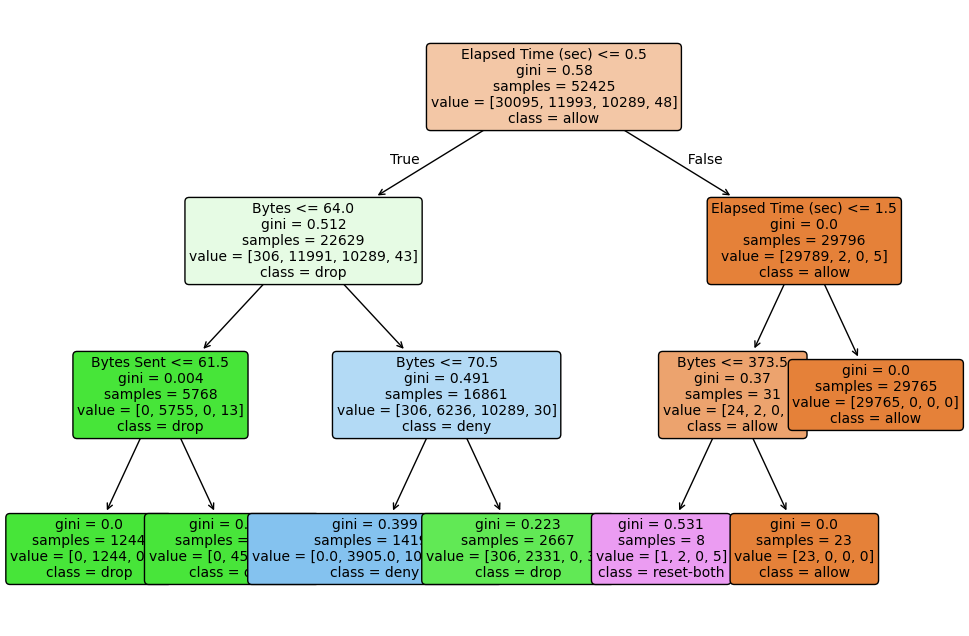

In [26]:
plt.figure(figsize=(12, 8))  # Set the window size
plot_tree(
    classifier,
    feature_names=columns.drop('Action').values,  
    class_names=df['Action'].unique().astype(str),  
    filled=True,  
    rounded=True, 
    fontsize=10, 
)

In [27]:
y_pred = classifier.predict(X_test)

              precision    recall  f1-score   support

       allow       1.00      0.99      0.99      7545
        deny       0.96      0.67      0.79      2994
        drop       0.72      1.00      0.84      2562
  reset-both       0.67      0.33      0.44         6

    accuracy                           0.92     13107
   macro avg       0.84      0.75      0.77     13107
weighted avg       0.94      0.92      0.92     13107



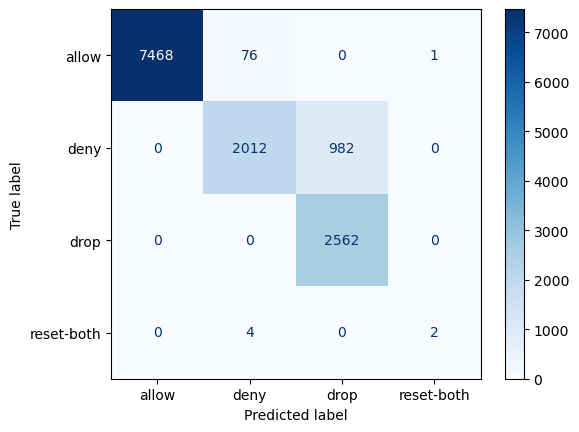

In [30]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [31]:
train_acc = classifier.score(X_train, y_train)
test_acc = classifier.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.2f}")
print(f"Testing Accuracy: {test_acc:.2f}")

Training Accuracy: 0.92
Testing Accuracy: 0.92


In [37]:
print(f"Tree Depth: {classifier.get_depth()}")
print(f"Number of Leaves: {classifier.get_n_leaves()}")

Tree Depth: 3
Number of Leaves: 7
